Today's topics:
* computing a new column from old ones
* storing it in the table
* bar charts
* dividing by zero
* `np.linspace` and `np.arange`
* `np.exp`

# Why is the mirror gold?

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/b/b1/Gold-coated_Primary_Mirror_Segment_%284976532481%29.jpg/960px-Gold-coated_Primary_Mirror_Segment_%284976532481%29.jpg" alt="An engineer in a white cleanroom suit inspecting a row of six hexagonal telescope mirror segments, each with a bright gold reflective surface" width=520/>

Photo by NASA's James Webb Space Telescope, public domain,
[via Wikimedia Commons](https://commons.wikimedia.org/wiki/File:Gold-coated_Primary_Mirror_Segment_(4976532481).jpg).

Last time we said gold makes a good infrared mirror because its $k$ is large, and we
left it there.

The file holds $n$ and $k$.

It doesn't hold a reflectance, a depth, or a transmission. Today we make all three.

In [1]:
#@title Find the data file and split it by material (click ▶ to run) { display-mode: "form" }
import os

import pandas as pd

_file = 'optical_constants.csv'
_github = f'https://raw.githubusercontent.com/wfreinhart/matse219/main/datasets/{_file}'
_local = next(
    (p for p in (f'datasets/{_file}', f'../datasets/{_file}', f'../../datasets/{_file}',
                 f'../../../datasets/{_file}')
     if os.path.exists(p)),
    None,
)
source = _local if _local else _github

try:
    _table = pd.read_csv(source)
except Exception as e:
    raise RuntimeError(
        f"Could not load '{_file}'. If you are in Colab, check your internet "
        f"connection and that the file exists at {_github}"
    ) from e

# Picking out one material's rows is boolean indexing, which is L11. Everything
# else in today's lecture happens in the open.
materials = {
    name: _table[_table['material'] == name].sort_values('wavelength_um').reset_index(drop=True)
    for name in ('silicon', 'BK7', 'fused_silica', 'gold')
}

print(f'Ready. Four materials split out of {_file}:')
for _name, _frame in materials.items():
    print(f'  {_name:14s} {len(_frame):2d} wavelengths')

Ready. Four materials split out of optical_constants.csv:
  silicon        11 wavelengths
  BK7            13 wavelengths
  fused_silica   10 wavelengths
  gold           13 wavelengths


The same four materials and the same dictionary as last time.

In [2]:
si = materials['silicon']
au = materials['gold']
bk7 = materials['BK7']
silica = materials['fused_silica']

display(au.head())

,material,wavelength_um,n,k
0,gold,0.1879,1.28,1.188
1,gold,0.2033,1.33,1.277
2,gold,0.2214,1.30,1.427
3,gold,0.2426,1.32,1.577
4,gold,0.2689,1.38,1.803


# A new column from two old ones

Every column we've plotted so far came out of a file.

A column can also be built, by writing an expression that uses more than one of the
columns we already have.

Optics gives us one to try. The fraction of light a surface sends straight back is

$$R = \frac{(n-1)^2 + k^2}{(n+1)^2 + k^2}$$

In [3]:
n = au['n']
k = au['k']

R_gold = ((n - 1)**2 + k**2) / ((n + 1)**2 + k**2)

print(R_gold)

0     0.225386
1     0.246419
2     0.290231
3     0.329041
4     0.380833
5     0.386111
6     0.386595
7     0.406732
8     0.401478
9     0.882363
10    0.974463
11    0.979520
12    0.980989
dtype: float64


Two columns went in and one came out, the same length as both.

Every operation ran once per wavelength, the way elementwise arithmetic always has.

> Note: `R_gold` is a column like any other. It can be printed, plotted, or used in
> the next expression.

## Storing it in the table

`R_gold` is sitting in a variable of its own, separate from the table it came from.

It can go into the table instead, under a name we choose.

In [4]:
au['R'] = R_gold

display(au.head())

,material,wavelength_um,n,k,R
0,gold,0.1879,1.28,1.188,0.225386
1,gold,0.2033,1.33,1.277,0.246419
2,gold,0.2214,1.30,1.427,0.290231
3,gold,0.2426,1.32,1.577,0.329041
4,gold,0.2689,1.38,1.803,0.380833


The table has five columns now. The fifth was not in the file.

Assigning to a name that doesn't exist yet adds a column. Assigning to one that does
replaces it.

> Note: in Lecture 8 we ran `pd.to_numeric` on a column and the table was unchanged
> afterward, because the result was never assigned anywhere. This is the line that
> was missing.

## The same expression on four materials

Let's write it three more times and put all four on one figure.

In [5]:
R_silicon = ((si['n'] - 1)**2 + si['k']**2) / ((si['n'] + 1)**2 + si['k']**2)
R_bk7 = ((bk7['n'] - 1)**2 + bk7['k']**2) / ((bk7['n'] + 1)**2 + bk7['k']**2)
R_silica = ((silica['n'] - 1)**2 + silica['k']**2) / ((silica['n'] + 1)**2 + silica['k']**2)

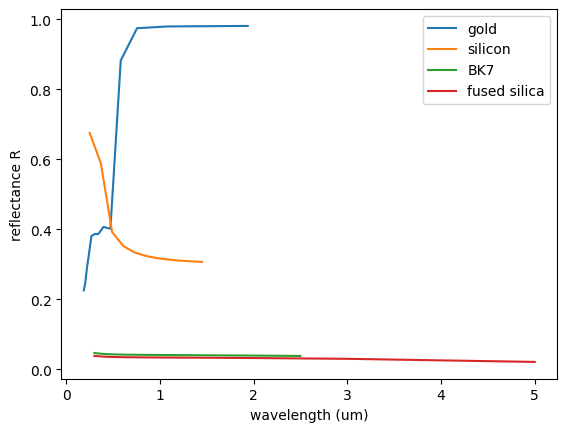

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.plot(au['wavelength_um'], R_gold, label='gold')
ax.plot(si['wavelength_um'], R_silicon, label='silicon')
ax.plot(bk7['wavelength_um'], R_bk7, label='BK7')
ax.plot(silica['wavelength_um'], R_silica, label='fused silica')
ax.set_xlabel('wavelength (um)')
ax.set_ylabel('reflectance R')
ax.legend()

Four `ax.plot` calls, four labels, one legend, exactly as in the last lecture. The
only new part is that the y values were computed rather than read.

Gold climbs to 98% in the infrared!

The glasses sit near 4%, which is why you can see through a window and still catch
your reflection in it at night.

> Note: the lines stop at different places because each material was measured over
> its own range of wavelengths.

### [Check your understanding]

1. Compute silicon's reflectance and store it in `si` under the name `R`.
2. Show the first few rows and check that the new column is there.
3. Make a `fig, ax` and plot `si['R']` against silicon's wavelengths, with a `label=`.
4. Add BK7 to the same figure with its own `label=`, label both axes, and draw the
   legend.
5. Which of the two reflects more, and does it do so everywhere?

## Comparing four numbers: `ax.bar`

The figure above has a lot in it. A shorter question is how high each material gets
at its best, which is four numbers rather than four curves.

`np.max` from Lecture 5 gives us each one.

In [7]:
import numpy as np

names = ['gold', 'silicon', 'BK7', 'fused silica']
peaks = [np.max(R_gold), np.max(R_silicon), np.max(R_bk7), np.max(R_silica)]

print(peaks)

[np.float64(0.9809892609988491), np.float64(0.675666988889403), np.float64(0.046888450333547875), np.float64(0.038445242931688356)]


`ax.bar` takes the labels and the heights, and draws one bar for each pair.

Text(0, 0.5, 'highest reflectance')

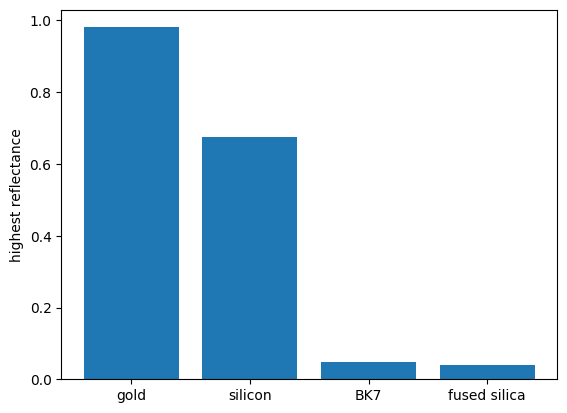

In [8]:
fig, ax = plt.subplots()
ax.bar(names, peaks)
ax.set_ylabel('highest reflectance')

The x axis is a list of names rather than a number line. Bars are the chart for a
quantity measured on categories, where a line would suggest the four materials sit in
some order.

Gold reaches 98%, silicon 68%, and the two glasses under 5%.

# A ratio of two columns

The same move again, with division instead.

The depth at which light has faded to about a third of what entered is

$$d = \frac{\lambda}{4 \pi k}$$

In [9]:
depth_gold = au['wavelength_um'] / (4 * np.pi * au['k'])
depth_silicon = si['wavelength_um'] / (4 * np.pi * si['k'])

print(depth_gold)

0     0.012586
1     0.012669
2     0.012346
3     0.012242
4     0.011868
5     0.012676
6     0.014567
7     0.016201
8     0.020288
9     0.016180
10    0.013245
11    0.012109
12    0.011186
dtype: float64


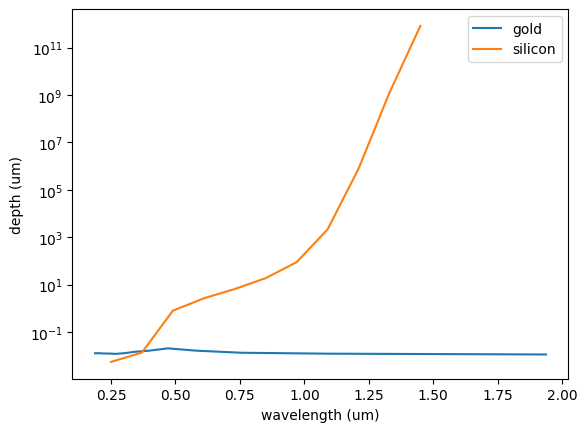

In [10]:
fig, ax = plt.subplots()
ax.plot(au['wavelength_um'], depth_gold, label='gold')
ax.plot(si['wavelength_um'], depth_silicon, label='silicon')
ax.set_xlabel('wavelength (um)')
ax.set_ylabel('depth (um)')
ax.set_yscale('log')
ax.legend()

Gold sits near a hundredth of a micrometer, about 16 nanometers in the red. Last
week's table said 13, reading a nearby wavelength off the same curve.

Silicon climbs through fourteen powers of ten, so the log axis from last lecture is
doing the same job here that it did for $k$.

## Dividing by zero

Fused silica is missing from that figure. Let's run the same line for it.

In [11]:
depth_silica = silica['wavelength_um'] / (4 * np.pi * silica['k'])

print(depth_silica.head())

0    inf
1    inf
2    inf
3    inf
4    inf
dtype: float64


`inf` is Python's infinity, and it's what division returns when the bottom is zero
and the top is not.

Nothing raised an error. NumPy divides by zero and reports the result, where
ordinary Python arithmetic would stop.

The answer is also correct. This file records silica's $k$ as exactly zero, and
light gets infinitely deep into a material that absorbs none of it.

> Note: a column of exact zeros is usually a gap in the measurement rather than a
> perfect material. Real fused silica absorbs past about 4 um, and this file doesn't
> record it.

# Values we choose: `np.linspace`

Every x axis so far came from a file.

Sometimes there's no column to plot against, because the quantity we want on the x
axis is one we pick.

A thickness is like that. Nobody measured it; we're deciding it.

In [12]:
thickness_um = np.linspace(0, 20, 100)

print(thickness_um[:5])
print(len(thickness_um))

[0.         0.2020202  0.4040404  0.60606061 0.80808081]
100


`np.linspace` takes a start, a stop and a count. It returns that many evenly spaced
values, with both ends included.

A hundred points is enough for a curve to look smooth without being slow to draw.

## A step instead of a count: `np.arange`

Sometimes we want to set the spacing directly.

`np.arange` takes a start, a stop and a step.

In [13]:
print(np.arange(0, 20, 2.5))

[ 0.   2.5  5.   7.5 10.  12.5 15.  17.5]


Eight values, 2.5 apart, and 20 is not among them. `np.arange` stops before the stop
value, where `np.linspace` includes it.

Use `np.linspace` when you want a smooth curve and don't care about the spacing, and
`np.arange` when the spacing is the physical thing, like a measurement every 5
degrees.

# Exponential decay: `np.exp`

`np.exp` raises $e$ to each value it's given, once per entry.

It shows up wherever something fades by the same fraction over each equal step,
which is what light does inside a material:

$$T = e^{-4 \pi k t / \lambda}$$

Text(0, 0.5, 'fraction still traveling')

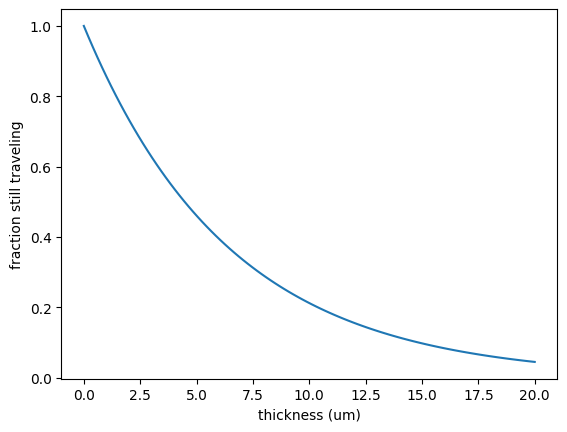

In [14]:
wavelength_um = 0.73
k_red = 0.009

T = np.exp(-4 * np.pi * k_red * thickness_um / wavelength_um)

fig, ax = plt.subplots()
ax.plot(thickness_um, T)
ax.set_xlabel('thickness (um)')
ax.set_ylabel('fraction still traveling')

The x values are ours and the y values come from the data, which is a new
combination for us.

Those are silicon's numbers for red light, from last week's table.

A silicon detector thinner than a few micrometers passes most of the red light
straight through.

## Marking a level: `ax.axhline`

The depth $d$ was defined as where the light has faded to $1/e$ of what entered,
which is about 0.37.

`ax.axhline` draws a horizontal line all the way across the axes at a y value we
give it, so we can see where the curve crosses that level.

Text(0, 0.5, 'fraction still traveling')

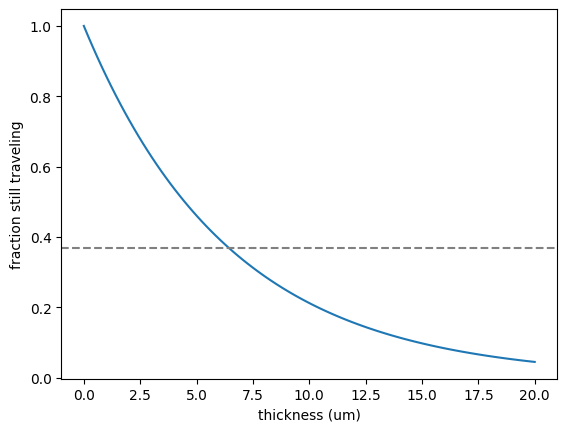

In [15]:
fig, ax = plt.subplots()
ax.plot(thickness_um, T)
ax.axhline(1 / np.e, color='gray', linestyle='--')
ax.set_xlabel('thickness (um)')
ax.set_ylabel('fraction still traveling')

The crossing is at about six and a half micrometers.

In [16]:
print(0.73 / (4 * np.pi * 0.009))

6.454617136504645


Which is the same 6.45 um that $\lambda / 4 \pi k$ gives, and the same depth last
week's table quoted as 6.5.

The formula and the curve are two ways of asking one question.

> Note: `ax.axvline` does the same thing vertically, at an x value.

### [Check your understanding]

1. Make a thickness axis from 0 to 100 nanometers with `np.linspace`, working in
   micrometers so the units match.
2. Compute the transmission through gold at red light, using $k = 4.5$ and the same
   0.73 um.
3. Plot it with both axes labeled, and add the $1/e$ line with `ax.axhline`.
4. Read the crossing off the figure, then compute $\lambda / 4 \pi k$ and check that
   the two agree.
5. Gold's depth is smaller than silicon's by a factor of a few hundred. Which of $k$
   or $\lambda$ is responsible?

# Summary

* An expression over two columns gives a new column of the same length.
* Assigning it into the table under a new name adds a column to the table.
* `ax.bar` charts a quantity measured on categories.
* NumPy returns `inf` for division by zero instead of raising.
* `np.linspace(start, stop, count)` makes evenly spaced values we choose, and
  `np.arange(start, stop, step)` chooses the spacing instead of the count.
* `np.exp` raises $e$ to every entry.
* `ax.axhline` marks a level across a figure.

Gold reflects 98% of infrared light and lets almost none of it in, which is what a
telescope mirror is for.

## Further reading

* The data: [Polyanskiy, *Scientific Data* **11**, 94 (2024)](https://doi.org/10.1038/s41597-023-02898-2),
  the refractiveindex.info database, CC BY 4.0. Browse it at
  [refractiveindex.info](https://refractiveindex.info).
* [Fresnel equations](https://en.wikipedia.org/wiki/Fresnel_equations), where the
  reflectance formula comes from, and what it looks like at other angles.